In [22]:
# importing necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sns.set_theme(style="whitegrid")

In [23]:
# SECTION 1: DATASET OVERVIEW
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_student_data, create_target

df_raw = load_student_data()
df = create_target(df_raw)

print("Dataset head: ", df.head())  # confirming dataset uploaded successfully
print("Dataset shape: ", df.shape)  # checking size of dataset
print("Columns in dataset: ", df.columns)  # checking the columns
print("Description of dataset: ", df.describe())
print("Dataset info: ", df.info())

Dataset head:    school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  freetime goout  Dalc  Walc  health absences  G1  G2  G3 needs_support  
0        3     4     1     1       3        4   0  11  11             0  
1        3     3     1     1       3        2   9  11  11             0  
2        3     2     2     3       3        6  12  13  12             0  
3        2     2     1     1       5        0  14  14  14             0  
4        3     2     1     2       5        0  11  13  13             0  

[5 rows x 34 columns]
Dataset shape:  (649, 34)
Colum

Dataset shape: (649, 33)
Missing values by column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64
Exact duplicate rows: 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649,649,649.000000,649,649,649,649.000000,649.000000,649,649,...,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
unique,2,2,NaN,2,2,2,NaN,NaN,5,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,GP,F,NaN,U,GT3,T,NaN,NaN,other,other,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,423,383,NaN,452,457,569,NaN,NaN,258,367,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,16.744222,NaN,NaN,NaN,2.514638,2.306626,NaN,NaN,...,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,NaN,NaN,1.218138,NaN,NaN,NaN,1.134552,1.099931,NaN,NaN,...,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,NaN,NaN,15.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,16.000000,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,...,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,NaN,NaN,17.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,...,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,NaN,NaN,18.000000,NaN,NaN,NaN,4.000000,3.000000,NaN,NaN,...,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000


G3 summary:
count    649.000000
mean      11.906009
std        3.230656
min        0.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       19.000000
Name: G3, dtype: float64
G3 value counts:
G3
0      15
1       1
5       1
6       3
7      10
8      35
9      35
10     97
11    104
12     72
13     82
14     63
15     49
16     36
17     29
18     15
19      2
Name: count, dtype: int64


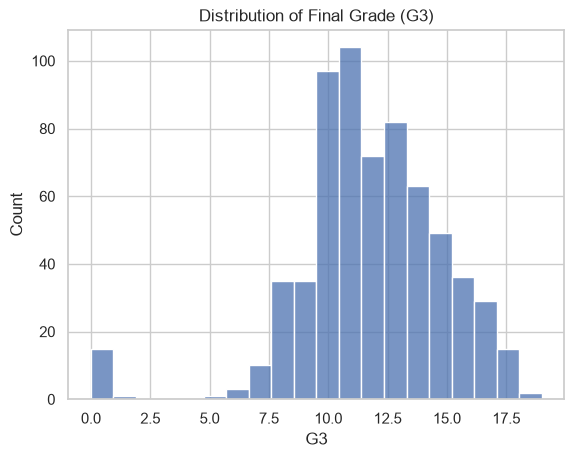

In [24]:
# SECTION 2: DATA QUALITY CHECK
print("Dataset shape:", df_raw.shape)
print("Missing values by column:")
print(df_raw.isnull().sum())  # checking for missing values
print(
    "Exact duplicate rows:", df_raw.duplicated().sum()
)  # checking for duplicated values
display(df_raw.describe(include="all"))
print("G3 summary:")
print(df_raw["G3"].describe())  # mathematical description of g3
print("G3 value counts:")
print(df_raw["G3"].value_counts().sort_index())

sns.histplot(df["G3"], bins=20)
plt.title("Distribution of Final Grade (G3)")
plt.show()

### Finding
- The dataset contains 649 rows and 33 original columns, with no missing values and no exact duplicate rows.
- G3 (final grade) ranges from 0–20 and is right-of-center concentrated, with a small cluster of students scoring 0.
- This confirms the foundation notebook's reported data quality and means no imputation or row removal is needed at this stage.
- Limitation: a G3 of 0 may represent a withdrawn/absent student rather than true academic failure — worth flagging, not silently treating the same as a low but genuine score.

Target Counts:
 needs_support
0    549
1    100
Name: count, dtype: int64

Target Proportion:
 needs_support
0    84.59168
1    15.40832
Name: proportion, dtype: float64


C:\Users\boham\AppData\Local\Temp\ipykernel_74904\2081275220.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="needs_support", data=df, palette=["#2ecc71", "#e74c3c"])


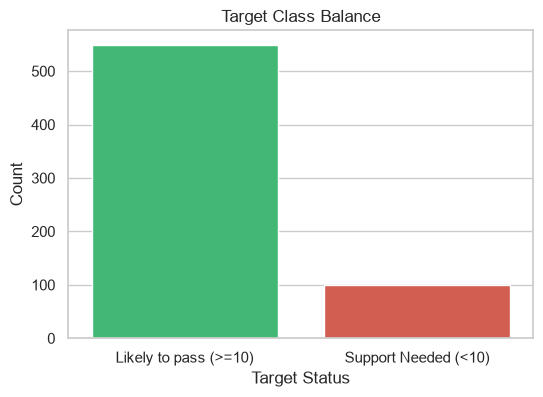

In [ ]:
print("Target Counts:\n", df["needs_support"].value_counts())
print("\nTarget Proportion:\n", df["needs_support"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x="needs_support", data=df, palette=["#2ecc71", "#e74c3c"])
plt.xticks([1, 0], ["Support Needed (<10)", "Likely to pass (>=10)"])
plt.title("Target Class Balance")
plt.xlabel("Target Status")
plt.ylabel("Count")
plt.show()

### Finding
- The class distribution is imbalanced: 549 students are "Likely to Pass" (needs_support=0) and 100 "May Need Support" (needs_support=1), roughly an 85/15 split.
- This imbalance is important for every downstream model — accuracy alone will be misleading, which is why the team prioritizes recall for needs_support=1 over overall accuracy.
- Relevant to both experiments equally, since the target itself doesn't change between early-warning and progress-informed setups.
- Limitation: with only 100 positive-class students, subgroup splits (by sex/school/address) will have small sample sizes — interpret cautiously.

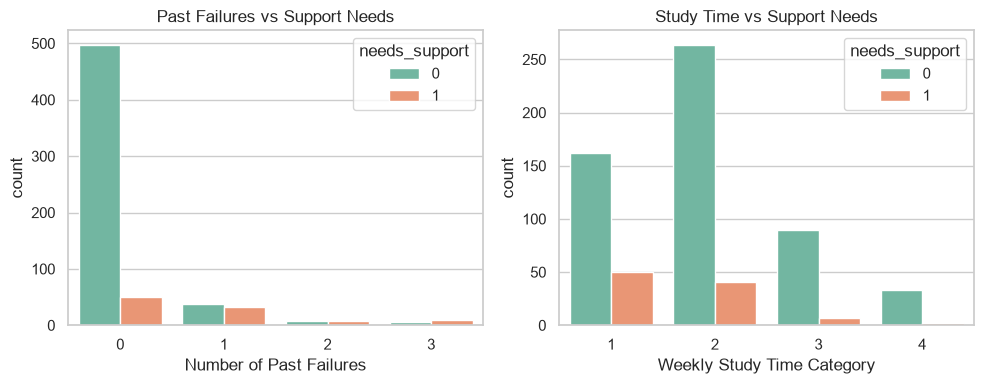

In [26]:
# TASK 3
plt.figure(figsize=(10, 4))

# past failures vs target status
plt.subplot(1, 2, 1)
sns.countplot(x="failures", hue="needs_support", data=df, palette="Set2")
plt.title("Past Failures vs Support Needs")
plt.xlabel("Number of Past Failures")

# weekly study time vs target status
plt.subplot(1, 2, 2)
sns.countplot(x="studytime", hue="needs_support", data=df, palette="Set2")
plt.title("Study Time vs Support Needs")
plt.xlabel("Weekly Study Time Category")

plt.tight_layout()
plt.show()

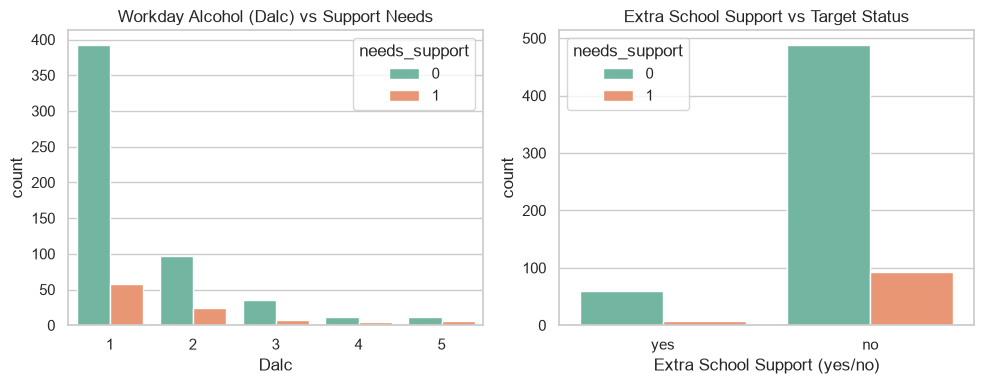

In [27]:
plt.figure(figsize=(10, 4))

# Workday alcohol consumption (dalc) vs target
plt.subplot(1, 2, 1)
sns.countplot(x="Dalc", hue="needs_support", data=df, palette="Set2")
plt.title("Workday Alcohol (Dalc) vs Support Needs")

# school support vs target
plt.subplot(1, 2, 2)
sns.countplot(x="schoolsup", hue="needs_support", data=df, palette="Set2")
plt.title("Extra School Support vs Target Status")
plt.xlabel("Extra School Support (yes/no)")

plt.tight_layout()
plt.show()

### Finding
- Students with more past failures show a visibly higher proportion needing support, consistent with failures being a strong early-warning signal.
- Study time and workday alcohol consumption show [describe the direction you actually see — e.g. "a mild inverse relationship" or "no clear pattern"] with support status.
- These are especially relevant to the early-warning experiment, since failures/studytime/Dalc are all available before G1/G2 exist.
- Limitation: these are simple bivariate views — they don't control for confounding variables (e.g. age, address) that a model would need to account for.

Correlations with Target:
 needs_support    1.000000
failures         0.380237
Dalc             0.123627
Walc             0.116249
age              0.110722
freetime         0.093349
absences         0.087483
goout            0.067241
traveltime       0.057869
health           0.009979
famrel          -0.044987
Medu            -0.144803
Fedu            -0.146249
studytime       -0.165111
G1              -0.563070
G2              -0.592251
G3              -0.663157
Name: needs_support, dtype: float64


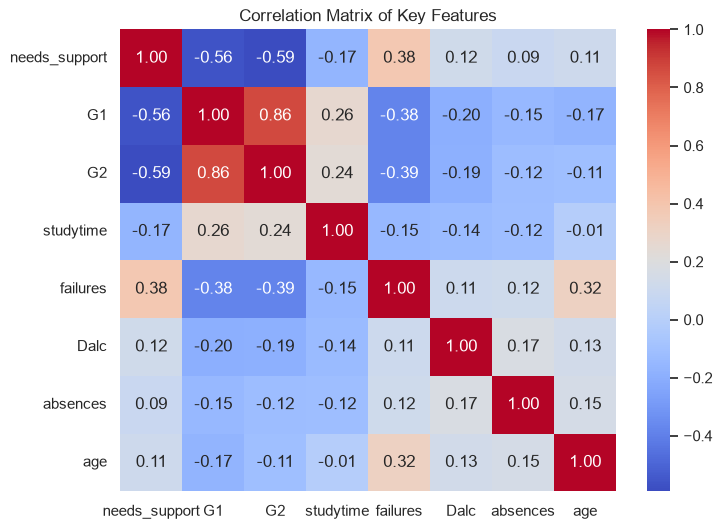

In [28]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
correlations = numeric_df.corr()["needs_support"].sort_values(ascending=False)

print("Correlations with Target:\n", correlations)

plt.figure(figsize=(8, 6))
key_cols = [
    "needs_support",
    "G1",
    "G2",
    "studytime",
    "failures",
    "Dalc",
    "absences",
    "age",
]
sns.heatmap(df[key_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Key Features")
plt.show()

### Finding
- G1 and G2 show the strongest correlation with needs_support ([fill in exact values]), which is expected since they are earlier measurements of the same underlying performance G3 captures.
- Because needs_support is derived directly from G3, any G3-target correlation is partly definitional and should not be read as model-input evidence — G3 is excluded from all model features regardless of its correlation strength.
- G1/G2's correlation is informative for the progress-informed experiment but irrelevant to early-warning, where both are excluded.
- Limitation: correlation only captures linear relationships; some categorical or non-linear patterns (e.g. failures) may matter more than this heatmap suggests.

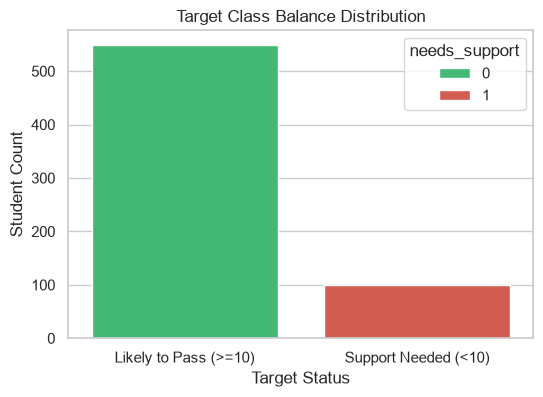

In [43]:
# TASK 4: Prepare EDA charts and findings
# ensuring output directory exists
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# CHART 1: Target Class Balance
plt.figure(figsize=(6, 4))
ax = sns.countplot(
    x="needs_support", hue="needs_support", data=df, palette=["#2ecc71", "#e74c3c"]
)
plt.xticks([0, 1], ["Likely to Pass (>=10)", "Support Needed (<10)"])
plt.title("Target Class Balance Distribution")
plt.xlabel("Target Status")
plt.ylabel("Student Count")
plt.savefig(FIGURES_DIR / "target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


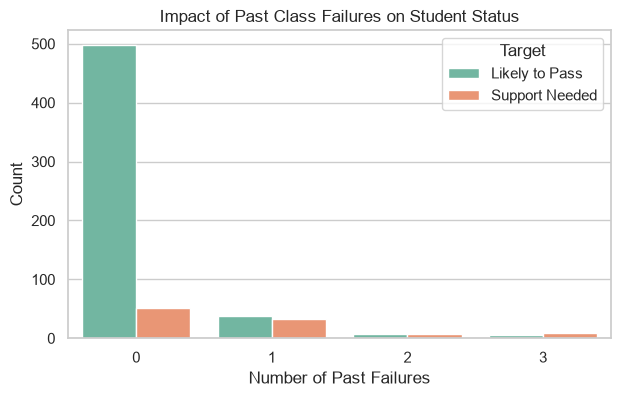

In [41]:
# CHART 2: Past Failures vs Support Needs
plt.figure(figsize=(7, 4))
sns.countplot(x="failures", hue="needs_support", data=df, palette="Set2")
plt.title("Impact of Past Class Failures on Student Status")
plt.xlabel("Number of Past Failures")
plt.ylabel("Count")
plt.legend(title="Target", labels=["Likely to Pass", "Support Needed"])
plt.savefig(FIGURES_DIR / "failures_vs_target.png", dpi=300, bbox_inches="tight")
plt.show()

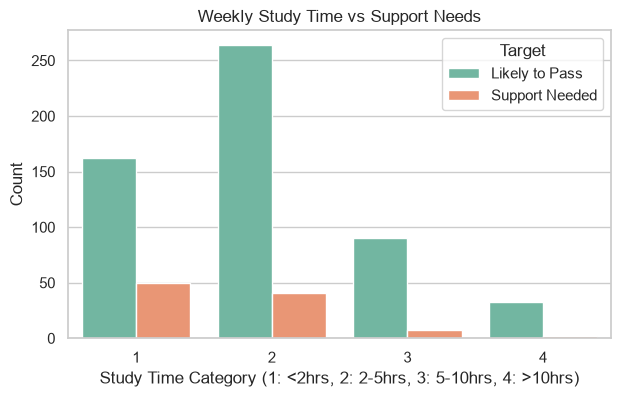

In [47]:
# CHART: Study Time vs Support Needs
plt.figure(figsize=(7, 4))
sns.countplot(x="studytime", hue="needs_support", data=df, palette="Set2")
plt.title("Weekly Study Time vs Support Needs")
plt.xlabel("Study Time Category (1: <2hrs, 2: 2-5hrs, 3: 5-10hrs, 4: >10hrs)")
plt.ylabel("Count")
plt.legend(title="Target", labels=["Likely to Pass", "Support Needed"])
plt.savefig(FIGURES_DIR / "studytime_by_support.png", dpi=300, bbox_inches="tight")
plt.show()

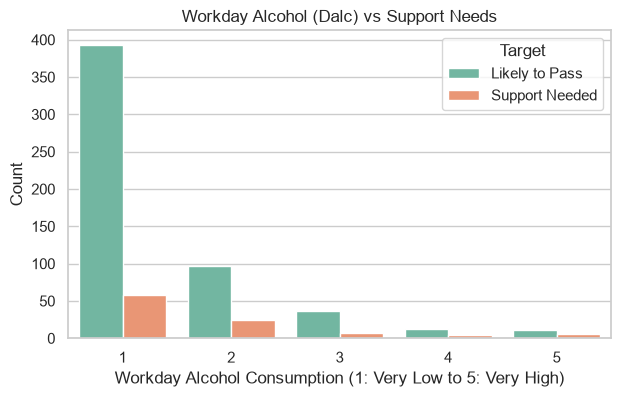

In [48]:
# CHART: Workday Alcohol (Dalc) vs Support Needs
plt.figure(figsize=(7, 4))
sns.countplot(x="Dalc", hue="needs_support", data=df, palette="Set2")
plt.title("Workday Alcohol (Dalc) vs Support Needs")
plt.xlabel("Workday Alcohol Consumption (1: Very Low to 5: Very High)")
plt.ylabel("Count")
plt.legend(title="Target", labels=["Likely to Pass", "Support Needed"])
plt.savefig(FIGURES_DIR / "alcohol_vs_support.png", dpi=300, bbox_inches="tight")
plt.show()

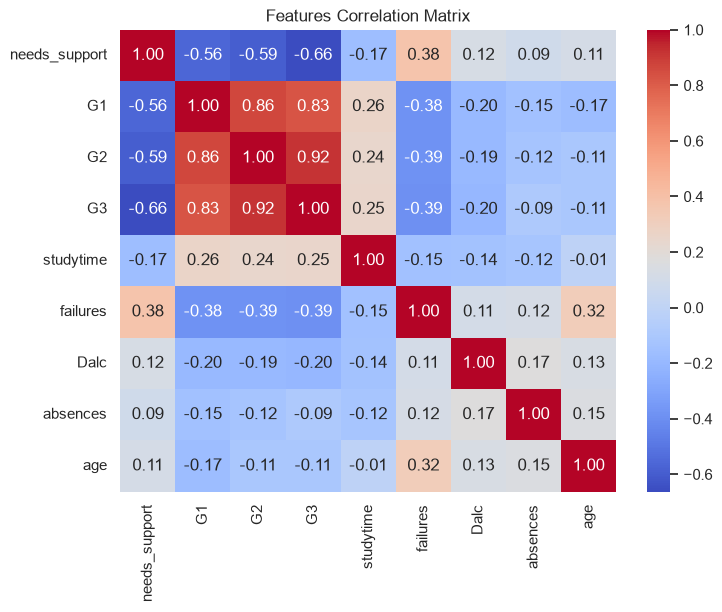

In [32]:
# CHART 4: Correlation Matrix
plt.figure(figsize=(8, 6))
key_cols = [
    "needs_support",
    "G1",
    "G2",
    "G3",
    "studytime",
    "failures",
    "Dalc",
    "absences",
    "age",
]
sns.heatmap(df[key_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Features Correlation Matrix")
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

--- sex ---
sex
F    383
M    266
Name: count, dtype: int64
sex
F    59.0
M    41.0
Name: proportion, dtype: float64

--- school ---
school
GP    423
MS    226
Name: count, dtype: int64
school
GP    65.2
MS    34.8
Name: proportion, dtype: float64

--- address ---
address
U    452
R    197
Name: count, dtype: int64
address
U    69.6
R    30.4
Name: proportion, dtype: float64

--- famsize ---
famsize
GT3    457
LE3    192
Name: count, dtype: int64
famsize
GT3    70.4
LE3    29.6
Name: proportion, dtype: float64

--- Pstatus ---
Pstatus
T    569
A     80
Name: count, dtype: int64
Pstatus
T    87.7
A    12.3
Name: proportion, dtype: float64

--- Mjob ---
Mjob
other       258
services    136
at_home     135
teacher      72
health       48
Name: count, dtype: int64
Mjob
other       39.8
services    21.0
at_home     20.8
teacher     11.1
health       7.4
Name: proportion, dtype: float64

--- Fjob ---
Fjob
other       367
services    181
at_home      42
teacher      36
health       23
Name: c

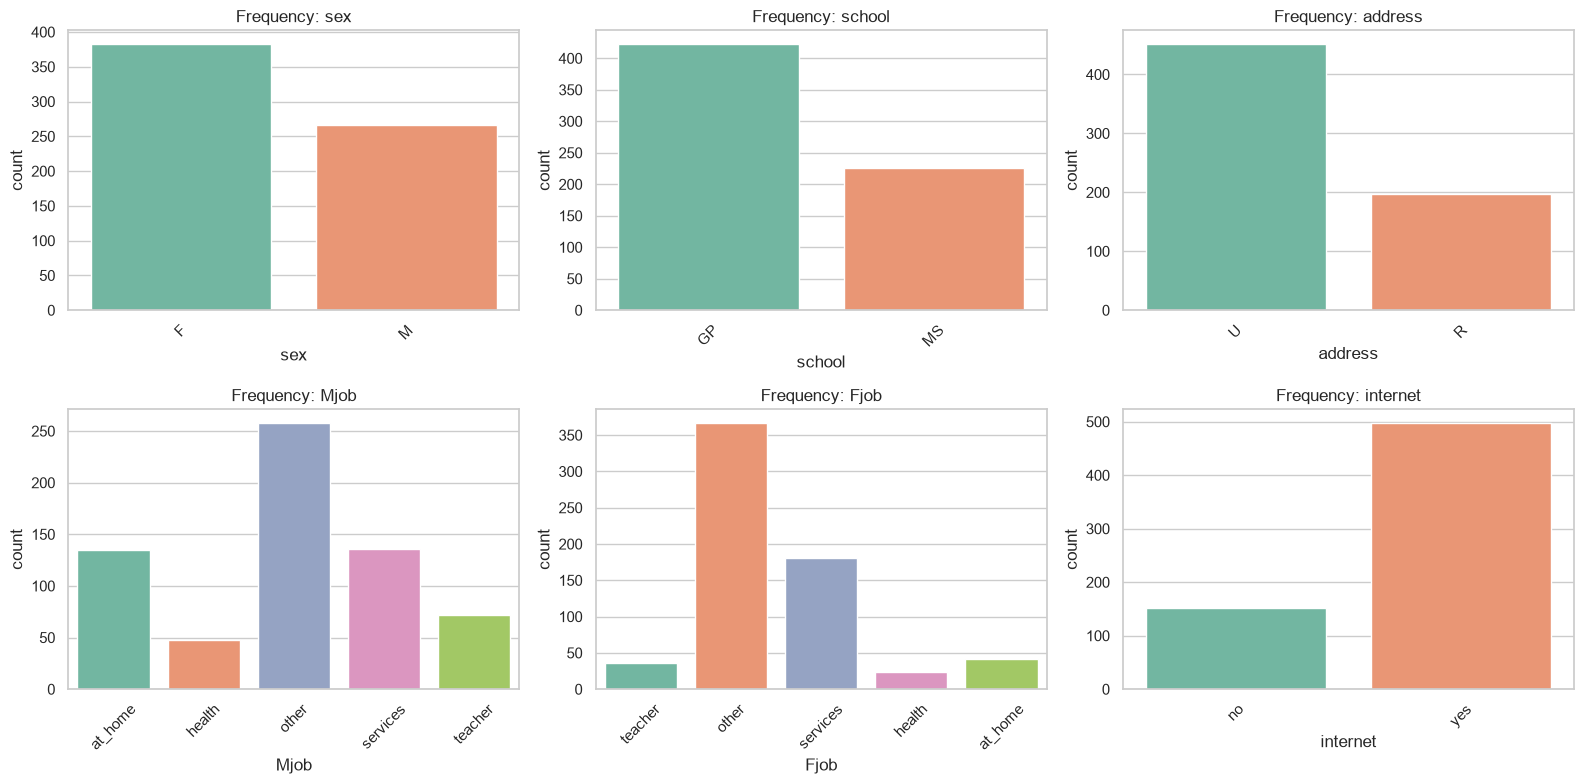

In [46]:
# CHART: Categorical Frequency Overview (selected columns)
# CATEGORICAL FREQUENCY SUMMARIES
categorical_cols = [
    "sex",
    "school",
    "address",
    "famsize",
    "Pstatus",
    "Mjob",
    "Fjob",
    "reason",
    "guardian",
    "schoolsup",
    "famsup",
    "paid",
    "activities",
    "nursery",
    "higher",
    "internet",
    "romantic",
]

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True).round(3) * 100)
    print()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
selected_cats = ["sex", "school", "address", "Mjob", "Fjob", "internet"]

for ax, col in zip(axes.flatten(), selected_cats):
    sns.countplot(x=col, data=df, ax=ax, palette="Set2", hue=col, legend=False)
    ax.set_title(f"Frequency: {col}")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "categorical_frequencies.png", dpi=300, bbox_inches="tight")
plt.show()

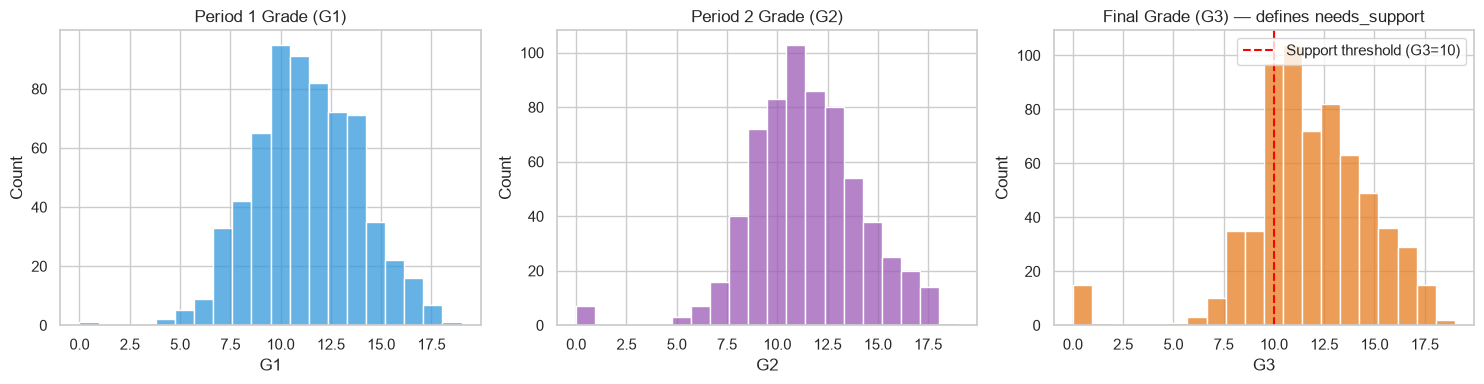

In [33]:
# CHART: Grade Distributions (G1, G2, G3)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["G1"], bins=20, ax=axes[0], color="#3498db")
axes[0].set_title("Period 1 Grade (G1)")
axes[0].set_xlabel("G1")

sns.histplot(df["G2"], bins=20, ax=axes[1], color="#9b59b6")
axes[1].set_title("Period 2 Grade (G2)")
axes[1].set_xlabel("G2")

sns.histplot(df["G3"], bins=20, ax=axes[2], color="#e67e22")
axes[2].set_title("Final Grade (G3) — defines needs_support")
axes[2].set_xlabel("G3")
axes[2].axvline(10, color="red", linestyle="--", label="Support threshold (G3=10)")
axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "grade_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

### Finding
- G1, G2, and G3 show similar overall shapes, reinforcing that final grade is a fairly stable extension of earlier performance rather than a sudden shift.
- The red threshold line at G3=10 visually shows how many students fall into the "needs support" region under the approved definition.
- Directly relevant to the progress-informed experiment, where G1/G2 are permitted features — this chart is part of justifying that decision.
- Limitation: this doesn't show the relationship between G1/G2 and needs_support directly — only their individual distributions.

C:\Users\boham\AppData\Local\Temp\ipykernel_74904\40445742.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="needs_support", y="absences", data=df, palette=["#2ecc71", "#e74c3c"])


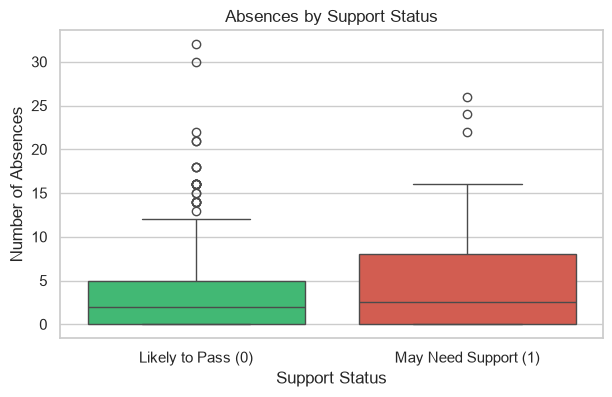

In [ ]:
# CHART: Absences by Support Status
plt.figure(figsize=(7, 4))
sns.boxplot(x="needs_support", y="absences", data=df, palette=["#2ecc71", "#e74c3c"])
plt.xticks([0, 1], ["Likely to Pass (0)", "May Need Support (1)"])
plt.title("Absences by Support Status")
plt.xlabel("Support Status")
plt.ylabel("Number of Absences")
plt.savefig(FIGURES_DIR / "absences_by_support.png", dpi=300, bbox_inches="tight")
plt.show()

### Finding
- Students needing support show [describe what you actually observe — e.g. "a higher median and wider spread of absences"] compared to those likely to pass.
- Absences are available early and don't depend on grades, making this a genuine early-warning-eligible feature.
- Limitation: absences could be a cause or a consequence of struggling academically — this chart shows association only, not direction of effect.

Support rate by sex:


,count,mean
sex,,
F,383,0.130548
M,266,0.187970


Support rate by school:


,count,mean
school,,
GP,423,0.075650
MS,226,0.300885


Support rate by address:


,count,mean
address,,
R,197,0.223350
U,452,0.123894


C:\Users\boham\AppData\Local\Temp\ipykernel_74904\2492574362.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subgroup_sex.index, y=subgroup_sex["mean"], ax=axes[0], palette="Set2")
C:\Users\boham\AppData\Local\Temp\ipykernel_74904\2492574362.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


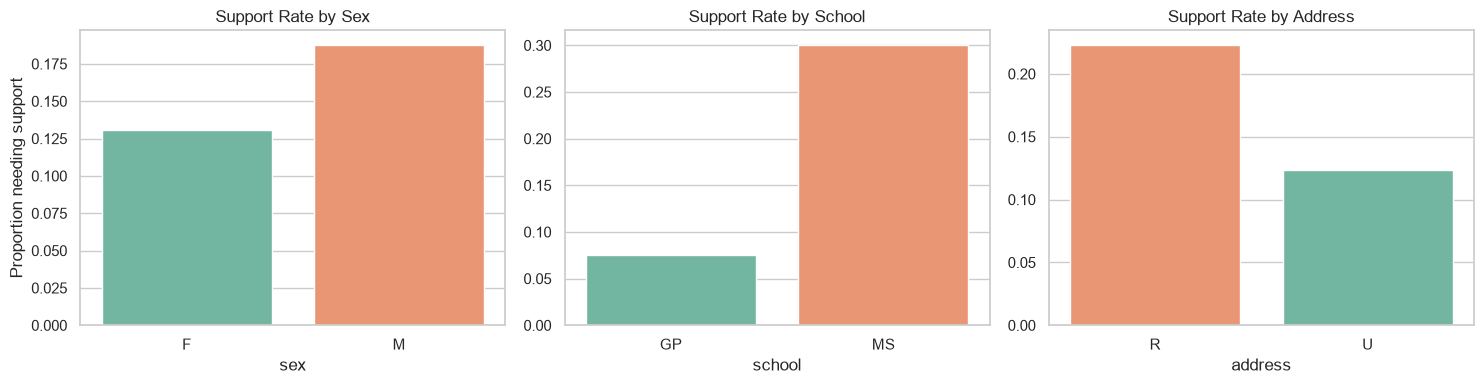

In [ ]:
# CHART + TABLE: Subgroup Summaries (sex, school, address)
subgroup_sex = df.groupby("sex")["needs_support"].agg(["count", "mean"])
subgroup_school = df.groupby("school")["needs_support"].agg(["count", "mean"])
subgroup_address = df.groupby("address")["needs_support"].agg(["count", "mean"])

print("Support rate by sex:")
display(subgroup_sex)
print("Support rate by school:")
display(subgroup_school)
print("Support rate by address:")
display(subgroup_address)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(x=subgroup_sex.index, y=subgroup_sex["mean"], ax=axes[0], palette="Set2")
axes[0].set_title("Support Rate by Sex")
axes[0].set_ylabel("Proportion needing support")

sns.barplot(
    x=subgroup_school.index, y=subgroup_school["mean"], ax=axes[1], palette="Set2"
)
axes[1].set_title("Support Rate by School")
axes[1].set_ylabel("")

address_colors = [
    "#fc8d62" if v == subgroup_address["mean"].max() else "#66c2a5"
    for v in subgroup_address["mean"]
]

sns.barplot(
    x=subgroup_address.index,
    y=subgroup_address["mean"],
    ax=axes[2],
    palette=address_colors,
    hue=subgroup_address.index,
    legend=False,
)
axes[2].set_title("Support Rate by Address")
axes[2].set_ylabel("")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "subgroup_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

### Finding
- Support rates vary by sex, school, and address ([fill in the actual proportions from your printed tables]).
- These differences are exploratory only — with subgroup sizes this small (especially within school/address splits), they should not be treated as conclusive fairness findings.
- This output is intended to hand off to Selorm's fairness analysis, not to draw conclusions here.
- Limitation: no statistical significance testing has been applied — apparent gaps could be due to sample size rather than a real effect.

## Handoff Summary

- No rows were removed from the original 649-row dataset.
- `needs_support` was defined as `G3 < 10`, matching the approved project convention (0 = likely to pass, 1 = may need support).
- No new train/test split was created in this notebook — the shared split from the foundation notebook remains authoritative.
- The raw CSV (`data/raw/student-por.csv`) was not modified.
- Required figures saved to `reports/figures/`: target_distribution.png, grade_distributions.png, absences_by_support.png, studytime_by_support.png, subgroup_distributions.png, correlation_heatmap.png.
- Subgroup summaries (sex, school, address) are ready for fairness analysis.